# Working with complicated dataset

Your name: Gloria Duo

### Question 1

blast_results: https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv

Read in the data from the csv file above. Skip all the comment lines, create a header for the dataframe based on the fields list in the comment line that starts with **# Fields:**. Drop the first column `query acc.ver`. Set the `subject acc.ver` as the index of the dataframe. The last column of the dataframe should be `publications`. Show the first five rows of the resulting dataframe.

In [61]:
# Preview the header, comments, and footer:
import urllib.request

url = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv"

with urllib.request.urlopen(url) as response:
    lines = [line.decode('utf-8').strip() for line in response.readlines()]

# Header (first 5 lines):
print("HEADER:")
for i, line in enumerate(lines[:5], start=1):
    print(f"{i}: {line}")

# Comments (start with '#'):
print("\nCOMMENTS:")
for i, line in enumerate(lines, start=1):
    if line.startswith("#"):
        print(f"{i}: {line}")

# Footer (last 5 lines):
print("\nFOOTER:")
for i, line in enumerate(lines[-5:], start=len(lines) - 4):
    print(f"{i}: {line}")

HEADER:
1: # blastp,,,,,,,,,,,,,,,
2: # Iteration: 0,,,,,,,,,,,,,,,
3: # Query: YP_220550.1 NADH dehydrogenase subunit 1 (mitochondrion) [Mus musculus domesticus],,,,,,,,,,,,,,,
4: # RID: 9SW3UNUT015,,,,,,,,,,,,,,,
5: # Database: nr,,,,,,,,,,,,,,,

COMMENTS:
1: # blastp,,,,,,,,,,,,,,,
2: # Iteration: 0,,,,,,,,,,,,,,,
3: # Query: YP_220550.1 NADH dehydrogenase subunit 1 (mitochondrion) [Mus musculus domesticus],,,,,,,,,,,,,,,
4: # RID: 9SW3UNUT015,,,,,,,,,,,,,,,
5: # Database: nr,,,,,,,,,,,,,,,
7: # 100 hits found,,,,,,,,,,,,,,,

FOOTER:
103: YP_220550.1,ABX45285.1,92.767,318,23,0,1,318,1,318,0,551,97.48," 17,348 ",6,
104: YP_220550.1,ASP44815.1,93.375,317,21,0,1,317,1,317,0,551,96.85," 7,105 ",19,
105: YP_220550.1,YP_009414156.1,84.543,317,49,0,1,317,1,317,0,551,94.01," 18,940 ",37,
106: YP_220550.1,YP_009414363.1,85.174,317,47,0,1,317,1,317,0,551,94.01," 18,762 ",5,
107: YP_220550.1,AGS12808.1,92.744,317,23,0,1,317,1,317,0,551,97.79," 3,209 ",32,


In [62]:
# Display contents of comment line that starts with "# Fields:":
print("\n# FIELDS COMMENT:")
for line in lines:
    if line.strip().startswith("# Fields:"):
        print(line)
        break


# FIELDS COMMENT:


In [63]:
# Since I don't see anything printed... let's view more of the comment section:
# I wrote it to a local file because Jupyter truncates output.
comments = [line for line in lines if line.strip().startswith("#")]

with open("comments.txt", "w") as f:
    for comment in comments:
        f.write(comment + "\n")

In [64]:
# I still don't see anything? 
# I opened the CSV file to check... 
# It turns out that the comment we're searching for is actually wrapped in quotes!!!
# So it's '"# Fields:"'...

# Let's parse this differently then:
for line in lines:
    if "# Fields:" in line:
        print(line)
        break

"# Fields: query acc.ver, subject acc.ver, % identity, alignment length, mismatches, gap opens, q. start, q. end, s. start, s. end, evalue, bit score, % positives, bonds, publications",,,,,,,,,,,,,,,


In [65]:
# Now that we've confirmed how to locate the line, we can extract the column names:
fields_line = ""

for line in lines:
    if "# Fields:" in line:
        fields_line = line
        print(fields_line)
        break

# Need to clean up the line first:
fields_line = fields_line.rstrip(",").strip('"')

# Grab columns:
columns = fields_line.replace("# Fields:", "").split(", ")
columns = [col.strip().strip('"') for col in columns]

print("\n Extracted columns:", columns)
print("\n Number of columns:", len(columns))

"# Fields: query acc.ver, subject acc.ver, % identity, alignment length, mismatches, gap opens, q. start, q. end, s. start, s. end, evalue, bit score, % positives, bonds, publications",,,,,,,,,,,,,,,

 Extracted columns: ['query acc.ver', 'subject acc.ver', '% identity', 'alignment length', 'mismatches', 'gap opens', 'q. start', 'q. end', 's. start', 's. end', 'evalue', 'bit score', '% positives', 'bonds', 'publications']

 Number of columns: 15


In [66]:
# Read the CSV file, skipping comments and using our extracted columns for the header:
import pandas as pd
from io import StringIO

clean_lines = [
    line for line in lines
    if not line.strip().startswith("#") and "# Fields:" not in line
]

df = pd.read_csv(StringIO("\n".join(clean_lines)), header=None)

df = df.iloc[:, :15] # Need to strip the last column in the data.

# Validate (should be equal):
# I realized that the data needs the last comma to be stripped, otherwise it registers as an extra column.
#print(df.shape[1])
#print(len(columns))

df.columns = columns

# View results:
df.head()

,query acc.ver,subject acc.ver,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications
0,YP_220550.1,NP_904328.1,100.000,318,0,0,1,318,1,318,0,629,100.00,"1,487",9
1,YP_220550.1,AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100.00,"17,947",47
2,YP_220550.1,YP_220563.1,99.686,318,1,0,1,318,1,318,0,627,100.00,"12,106",13
3,YP_220550.1,ACM24502.1,99.686,318,1,0,1,318,1,318,0,627,99.69,"2,319",41
4,YP_220550.1,AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100.00,"18,964",3


In [67]:
# Now we can drop the first column (query acc.ver):
df = df.drop(columns=["query acc.ver"])

# View results:
df.head()

,subject acc.ver,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications
0,NP_904328.1,100.000,318,0,0,1,318,1,318,0,629,100.00,"1,487",9
1,AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100.00,"17,947",47
2,YP_220563.1,99.686,318,1,0,1,318,1,318,0,627,100.00,"12,106",13
3,ACM24502.1,99.686,318,1,0,1,318,1,318,0,627,99.69,"2,319",41
4,AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100.00,"18,964",3


In [68]:
# Set the second column (subject acc.ver) to be the index:
df.set_index("subject acc.ver", inplace=True)

# View results:
df.head()

,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications
subject acc.ver,,,,,,,,,,,,,
NP_904328.1,100.000,318,0,0,1,318,1,318,0,629,100.00,"1,487",9
AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100.00,"17,947",47
YP_220563.1,99.686,318,1,0,1,318,1,318,0,627,100.00,"12,106",13
ACM24502.1,99.686,318,1,0,1,318,1,318,0,627,99.69,"2,319",41
AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100.00,"18,964",3


### Question 2
What is the average number of publications?

In [69]:
# Currently, publications is of type string (as displayed):
print("Data type of 'publications' feature (before):", df["publications"].dtype)

# Let's examine the contents of this column:
print("Displaying the contents of publications...\n")
print(df["publications"].value_counts())

Data type of 'publications' feature (before): str
Displaying the contents of publications...

publications
7     4
21    4
46    4
36    4
52    4
5     4
47    3
13    3
41    3
14    3
37    3
22    3
45    3
-     3
34    3
10    3
9     2
39    2
15    2
48    2
35    2
26    2
6     2
33    2
16    2
8     2
19    2
12    2
44    2
42    2
31    2
11    2
3     1
29    1
18    1
30    1
43    1
20    1
23    1
51    1
38    1
25    1
40    1
4     1
17    1
32    1
Name: count, dtype: int64


In [70]:
# I found the issue: missing values are marked with "-" instead of "NaN". 
# Convert "-" to "NaN" for pandas functions:
df["publications"] = pd.to_numeric(df["publications"], errors="coerce")

# Let's examine the contents of this column again (value_counts() excludes NaN by default, so we shouldn't see it):
print("Displaying the contents of publications...\n")
print(df["publications"].value_counts())

Displaying the contents of publications...

publications
7.0     4
21.0    4
46.0    4
36.0    4
52.0    4
5.0     4
47.0    3
13.0    3
41.0    3
14.0    3
37.0    3
22.0    3
45.0    3
34.0    3
10.0    3
9.0     2
39.0    2
15.0    2
48.0    2
35.0    2
26.0    2
6.0     2
33.0    2
16.0    2
8.0     2
19.0    2
12.0    2
44.0    2
42.0    2
31.0    2
11.0    2
3.0     1
29.0    1
18.0    1
30.0    1
43.0    1
20.0    1
23.0    1
51.0    1
38.0    1
25.0    1
40.0    1
4.0     1
17.0    1
32.0    1
Name: count, dtype: int64


In [71]:
# Calculate the average number of publications:
average_publications = df["publications"].mean()
print(f"The average number of publications is: {average_publications:.2f}")

The average number of publications is: 26.99


### Question 3
List the `subject acc.ver` that has over 15,000 bonds.

In [72]:
# bonds is also currently a string:
print("Data type of bonds (before):", df["bonds"].dtype)

# View values stored in bonds:
print("Displaying the contents of bonds...\n")
print(df["bonds"].value_counts())

Data type of bonds (before): str
Displaying the contents of bonds...

bonds
1,487      1
17,947     1
12,106     1
2,319      1
18,964     1
          ..
17,348     1
7,105      1
18,940     1
18,762     1
3,209      1
Name: count, Length: 100, dtype: int64


In [75]:
# We need to normalize the values first before converting to a numeric:
df["bonds"] = df["bonds"].str.replace(",", "", regex=False)

# View contents again:
print("Displaying the contents of bonds...\n")
print(df["bonds"].value_counts())

Displaying the contents of bonds...

bonds
1487      1
17947     1
12106     1
2319      1
18964     1
         ..
17348     1
7105      1
18940     1
18762     1
3209      1
Name: count, Length: 100, dtype: int64


In [76]:
# Convert bonds to numeric:
df["bonds"] = pd.to_numeric(df["bonds"], errors="coerce")

# Verify change:
print("Data type of bonds (after):", df["bonds"].dtype)

Data type of bonds (after): int64


In [79]:
# List all 'subject acc.ver' with bonds exceeding 15,000:
target_subjectAV = df.index[df["bonds"] > 15000]
print("subject acc.ver with over 15,000 bonds:\n")
print(target_subjectAV)

subject acc.ver with over 15,000 bonds:

Index(['AGK29621.1', 'AHG32084.1', '6G2J_H', 'YP_002791042.1', 'AGK29634.1',
       '0806162F', 'YP_009112408.1', 'YP_001876469.1', 'YP_009092269.1',
       'AHG32149.1', 'YP_009092074.1', 'YP_009450474.1', 'YP_004123270.1',
       'YP_009092073.1', 'AHZ60901.1', 'YP_004123350.1', 'YP_009453754.1',
       'ADD46492.1', 'YP_007025968.1', 'YP_009453806.1', 'YP_007024956.1',
       'ASM92364.1', 'YP_006073044.1', 'ASM92494.1', 'ADG95699.1',
       'YP_004891275.1', 'YP_009166014.1', 'YP_009538416.1', 'YP_009414182.1',
       'YP_009178854.1', 'YP_009414415.1', 'YP_009353908.1', 'YP_009093743.1',
       'ABX45285.1', 'YP_009414156.1', 'YP_009414363.1'],
      dtype='str', name='subject acc.ver')


### Question 4
Create a plot that shows the correlation between `% identity` and `% positives`.

In [80]:
# Check the data types before plotting:
print("Data type of % identity:", df["% identity"].dtype)
print("Data type of % positives:", df["% identity"].dtype)

Data type of % identity: float64
Data type of % positives: float64


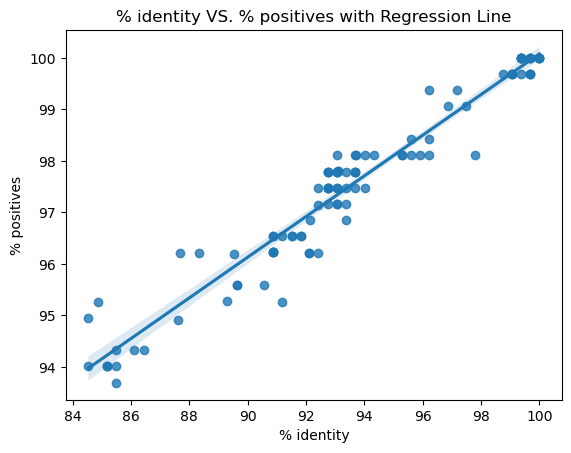

In [82]:
# We'll use a scatter plot + regression line to display the correlation:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(x="% identity", y="% positives", data=df)
plt.title("% identity VS. % positives with Regression Line")
plt.show()

### Question  5
Add a column `Protein source` to the dataframe from Question 1 based on the data in this csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv. Merge the data when the `subject acc.ver` from the dataframe equals to `Protein` in the csv file. Entries without a matching protein will have `NA` as `Protein source`.

In [83]:
# Load in secondary dataset:
protein_source = pd.read_csv("https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv")

# Preview contents: 
protein_source.head()

,Unnamed: 0,Protein,Source
0,0,NP_904328.1,RefSeq
1,2,YP_220563.1,GenPept
2,12,YP_002791042.1,GenPept
3,13,YP_001686698.1,GenPept
4,21,YP_009112408.1,GenPept


In [90]:
# Join secondary dataset w/ primary dataset on Protein = subject acc.ver:
df_merged = pd.merge(
    df,
    protein_source[["Protein", "Source"]], # Just need the Source feature from the secondary dataset. Still need to keep Protein to merge.
    left_index=True, # Need this because we're joining on the index of primary dataframe, not just a column.
    right_on="Protein",
    how="left" # No matches -> entries have NA as protein source. I'm assuming NA == NaN here, otherwise we can manually replace.
).set_index("Protein")

# View results:
df_merged.head()

,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications,Source
Protein,,,,,,,,,,,,,,
NP_904328.1,100.000,318,0,0,1,318,1,318,0,629,100.00,1487,9.0,RefSeq
AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100.00,17947,47.0,NaN
YP_220563.1,99.686,318,1,0,1,318,1,318,0,627,100.00,12106,13.0,GenPept
ACM24502.1,99.686,318,1,0,1,318,1,318,0,627,99.69,2319,41.0,NaN
AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100.00,18964,3.0,NaN


In [91]:
# Change the index name back to subject ver.acc & rename Source to Protein Source:
df_merged.index.name = "subject acc.ver"
df_merged = df_merged.rename(columns={"Source": "Protein Source"})

# View results:
df_merged.head()

,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications,Protein Source
subject acc.ver,,,,,,,,,,,,,,
NP_904328.1,100.000,318,0,0,1,318,1,318,0,629,100.00,1487,9.0,RefSeq
AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100.00,17947,47.0,NaN
YP_220563.1,99.686,318,1,0,1,318,1,318,0,627,100.00,12106,13.0,GenPept
ACM24502.1,99.686,318,1,0,1,318,1,318,0,627,99.69,2319,41.0,NaN
AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100.00,18964,3.0,NaN
